**Yield Curve PCA Analysis**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fbourgey/fre-gy-7773-mlfe/blob/main/07_yield_curve_pca_solution.ipynb)

- Given yields $y_t(\tau_j)$ for dates $t\in\{1,\ldots,T\}$ and 
maturities $\tau_j$, $j\in\{1,\ldots,M\}$.

- **Step 1**: Data matrix and centering
$$
    Y \in \mathbb{R}^{T \times M}, \quad Y_{t,j} = y_t(\tau_j),
    \quad \mu_j = \frac{1}{T} \sum_{t=1}^T Y_{t,j}, \quad X_{t,j} = Y_{t,j} - \mu_j.
$$ 

- **Step 2**: Covariance matrix across maturities

$$
    \Sigma = \frac{1}{T-1} X^\top X \in \mathbb{R}^{M \times M}.
$$

- **Step 3**: Eigen-decomposition (PCA). Loadings across the curve.

    $$
        \Sigma u_k = \lambda_k u_k, \qquad k\in\{1,\ldots,M\},
    $$
    where: 
    - $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_M \geq 0$ the eigenvalues
    - $u_k \in \mathbb{R}^M$ are the eigenvectors (loadings). They represent
        the shape of the yield curve components.

- **Step 4**: Scores (factor time series)

    $$
        f_k(t) = X_{t,\cdot} \, u_k, \quad t=1,\ldots,T.
    $$

- **Step 5**: Rank-$K$ reconstruction. Let $U = [u_1, \ldots, u_M] \in \mathbb{R}^{M \times M}$
and $F = [f_1, \ldots, f_M] \in \mathbb{R}^{T \times M}$.

    $$
        Y^{(K)} = \mathbf{1} \mu^{\top} + \sum_{k=1}^K f_k \, u_k^\top \in \mathbb{R}^{T \times M}
    $$

- **Step 6**: Explained variance

    $$
        \text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^M \lambda_j}.
    $$

- **Step 7**: Interpretation of components

    - Level (1st component, $u_1$): Parallel shifts in the yield curve.
    - Slope (2nd component, $u_2$): Changes in the steepness of the yield curve.
    - Curvature (3rd component, $u_3$): Changes in the curvature of the yield curve.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import datetime as dt
from pandas_datareader import data as web
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (8, 6)

## Load data

In [3]:
start = dt.datetime(2010, 1, 1)
end = dt.datetime.today()

# Constant-maturity Treasury series from FRED
fred_tickers = [
    "DGS1MO",
    "DGS3MO",
    "DGS6MO",
    "DGS1",
    "DGS2",
    "DGS3",
    "DGS5",
    "DGS7",
    "DGS10",
    "DGS20",
    "DGS30",
]

n_mats = len(fred_tickers)

# Load data from local CSV or download from FRED
# Set to False to download from FRED
load = True
if load:
    yields = pd.read_csv("data/yields.csv", index_col=0, parse_dates=True)
else:
    yields = pd.concat(
        [web.DataReader(t, "fred", start, end) for t in fred_tickers], axis=1
    )
df_yields = yields.dropna()
df_yields.columns = fred_tickers
df_yields /= 100.0  # convert to decimals

In [4]:
df_yields.head()

,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30
DATE,,,,,,,,,,,
2010-01-04,0.0005,0.0008,0.0018,0.0045,0.0109,0.0166,0.0265,0.0336,0.0385,0.0460,0.0465
2010-01-05,0.0003,0.0007,0.0017,0.0041,0.0101,0.0157,0.0256,0.0328,0.0377,0.0454,0.0459
2010-01-06,0.0003,0.0006,0.0015,0.0040,0.0101,0.0160,0.0260,0.0333,0.0385,0.0463,0.0470
2010-01-07,0.0002,0.0005,0.0016,0.0040,0.0103,0.0162,0.0262,0.0333,0.0385,0.0462,0.0469
2010-01-08,0.0002,0.0005,0.0015,0.0037,0.0096,0.0156,0.0257,0.0331,0.0383,0.0461,0.0470


Prepare data

In [5]:
Y = df_yields.values  # shape (T, M)
mu = Y.mean(axis=0, keepdims=True)
X = Y - mu  # centered data
cov_X = np.cov(X, rowvar=False)  # (M, M) covariance matrix

In [6]:
print(cov_X.shape)

(11, 11)


Perform PCA

In [7]:
U, S, U_transpose = np.linalg.svd(cov_X)
explained_variance = S / S.sum()

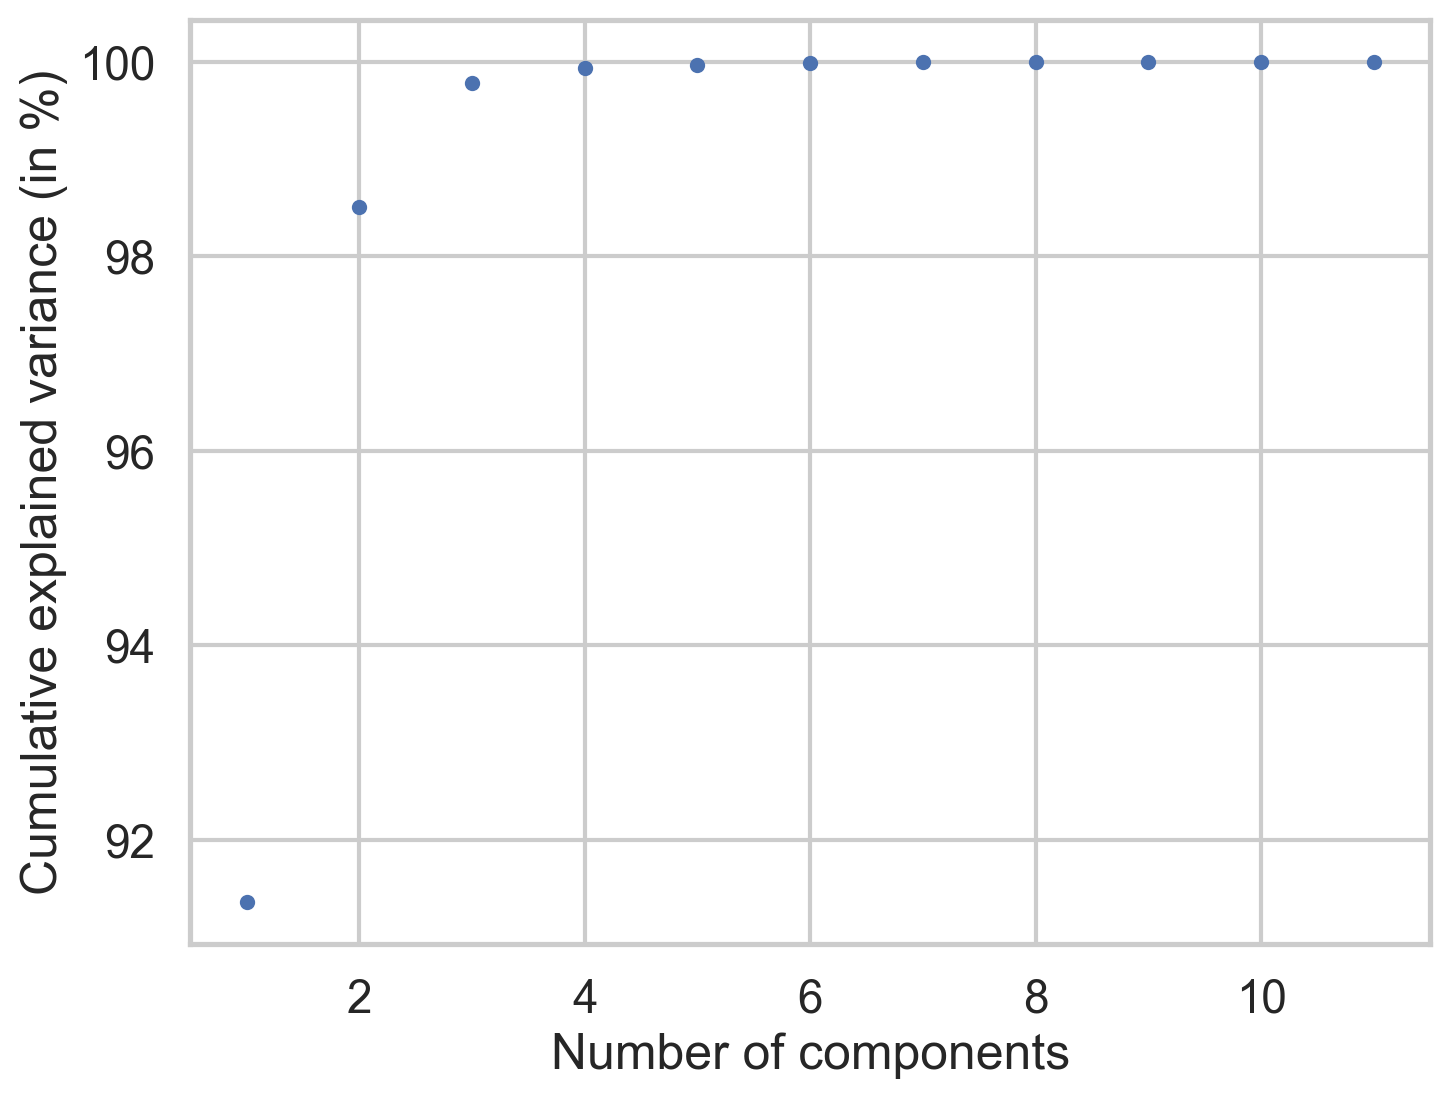

In [8]:
fig, ax = plt.subplots()
ax.plot(range(1, n_mats + 1), 100 * explained_variance.cumsum(), ".")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (in %)")
plt.show()

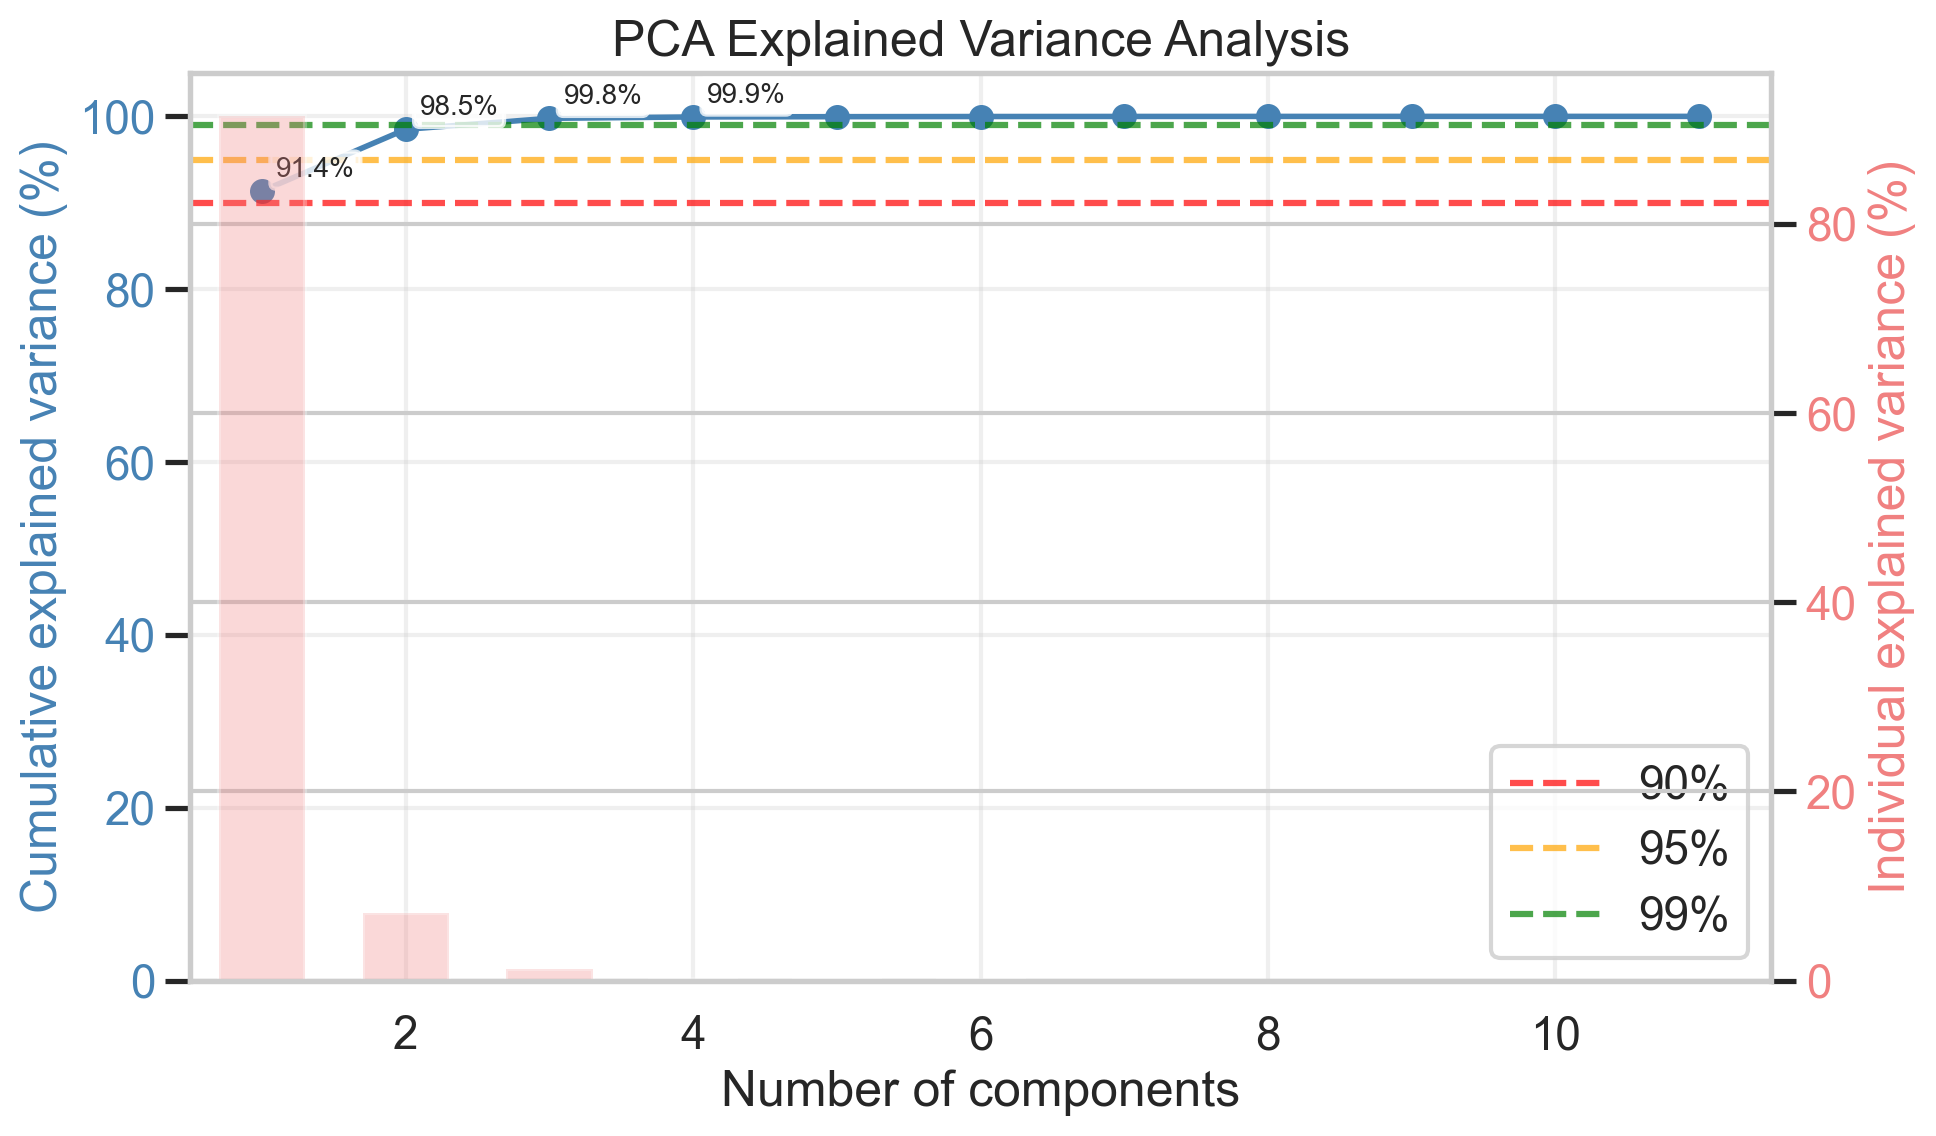

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# plot cumulative explained variance with better styling
ax.plot(
    range(1, n_mats + 1),
    100 * explained_variance.cumsum(),
    "o-",
    linewidth=2,
    markersize=8,
    color="steelblue",
)

# add individual explained variance as bars
ax2 = ax.twinx()
ax2.bar(
    range(1, n_mats + 1),
    100 * explained_variance,
    alpha=0.3,
    color="lightcoral",
    width=0.6,
    label="Individual",
)

# add horizontal reference lines
ax.axhline(y=90, color="red", linestyle="--", alpha=0.7, label="90%")
ax.axhline(y=95, color="orange", linestyle="--", alpha=0.7, label="95%")
ax.axhline(y=99, color="green", linestyle="--", alpha=0.7, label="99%")

# annotations for first few components
for i in range(min(4, n_mats)):
    cumvar = 100 * explained_variance[: i + 1].sum()
    ax.annotate(
        f"{cumvar:.1f}%",
        xy=(i + 1, cumvar),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.8},
    )

# styling
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance (%)", color="steelblue")
ax2.set_ylabel("Individual explained variance (%)", color="lightcoral")
ax.set_title("PCA Explained Variance Analysis")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
ax.set_xlim(0.5, n_mats + 0.5)
ax.set_ylim(0, 105)

# color the y-axis labels to match the data
ax.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="lightcoral")

plt.tight_layout()
plt.show()

In [10]:
# print summary statistics
print(
    f"First 3 components explain {100 * explained_variance[:3].sum():.1f}% of variance"
)
print(
    "Components needed for 95% variance: "
    f"{np.argmax(explained_variance.cumsum() >= 0.95) + 1}"
)
print(
    "Components needed for 99% variance: "
    f"{np.argmax(explained_variance.cumsum() >= 0.99) + 1}"
)

First 3 components explain 99.8% of variance
Components needed for 95% variance: 2
Components needed for 99% variance: 3


In [11]:
list_dates = df_yields.index.tolist()

Pick a specific date

In [30]:
date = dt.datetime(2025, 9, 24)

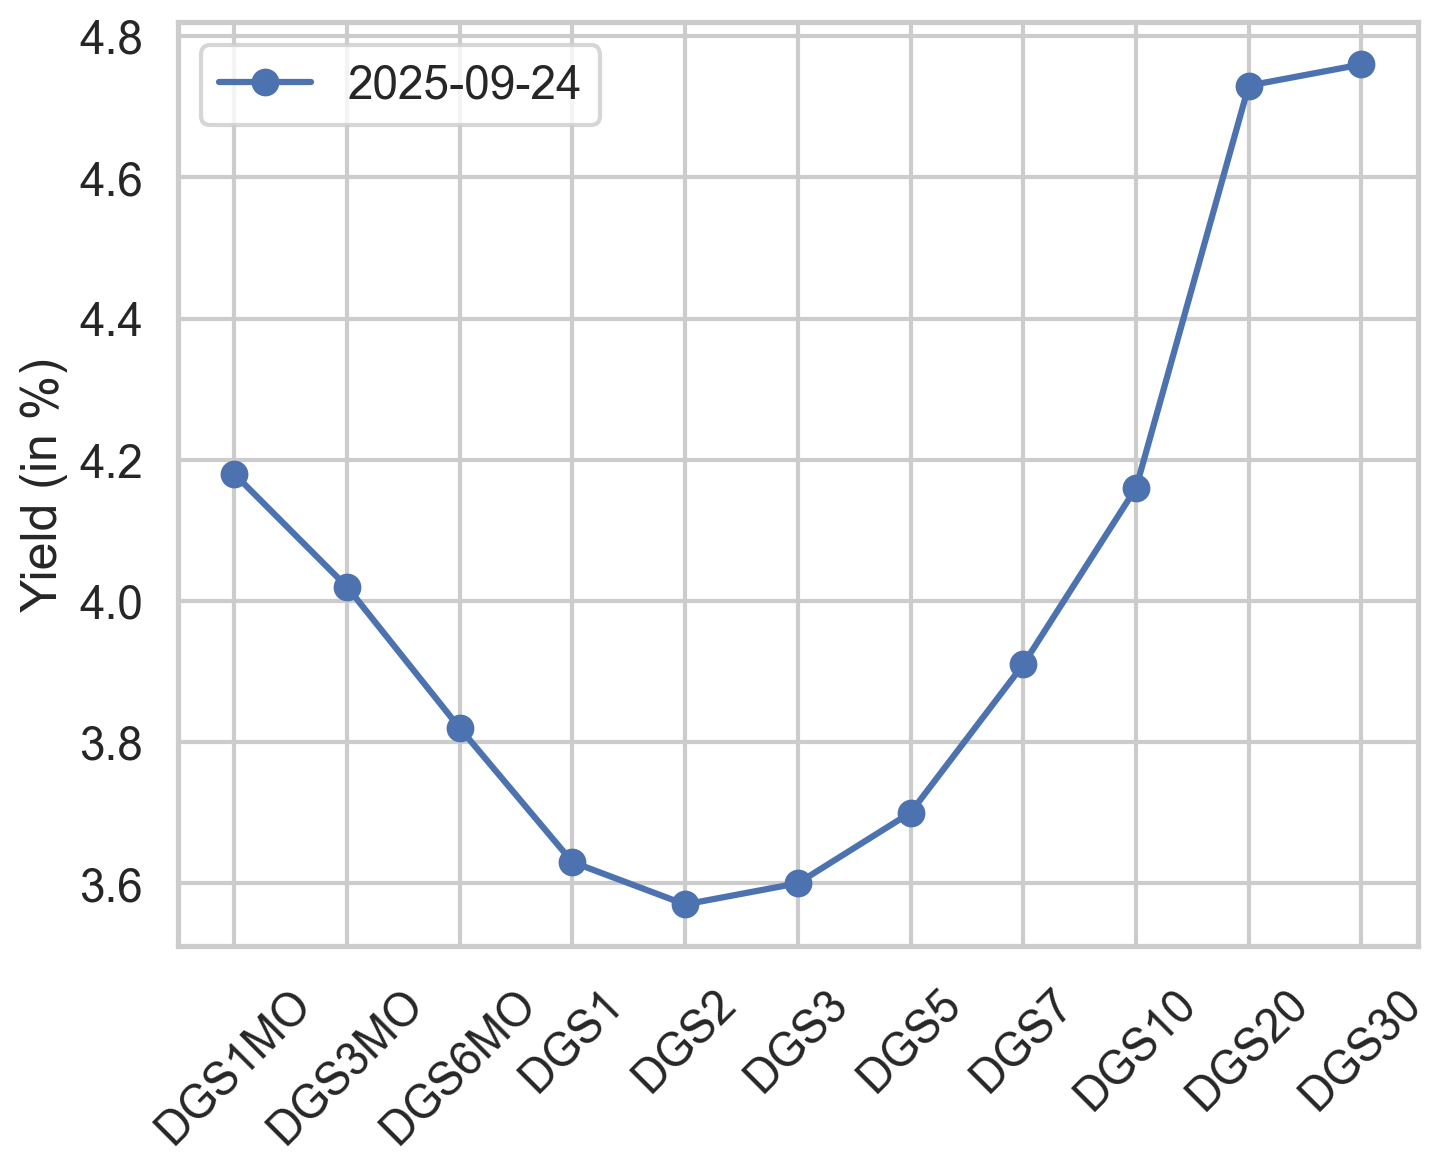

In [31]:
fig, ax = plt.subplots()
ax.plot(
    fred_tickers,
    100 * df_yields.loc[date],
    "o-",
    label=f"{date.strftime('%Y-%m-%d')}",
)
ax.legend()
ax.set_ylabel("Yield (in %)")
ax.tick_params(axis="x", rotation=45)
plt.show()

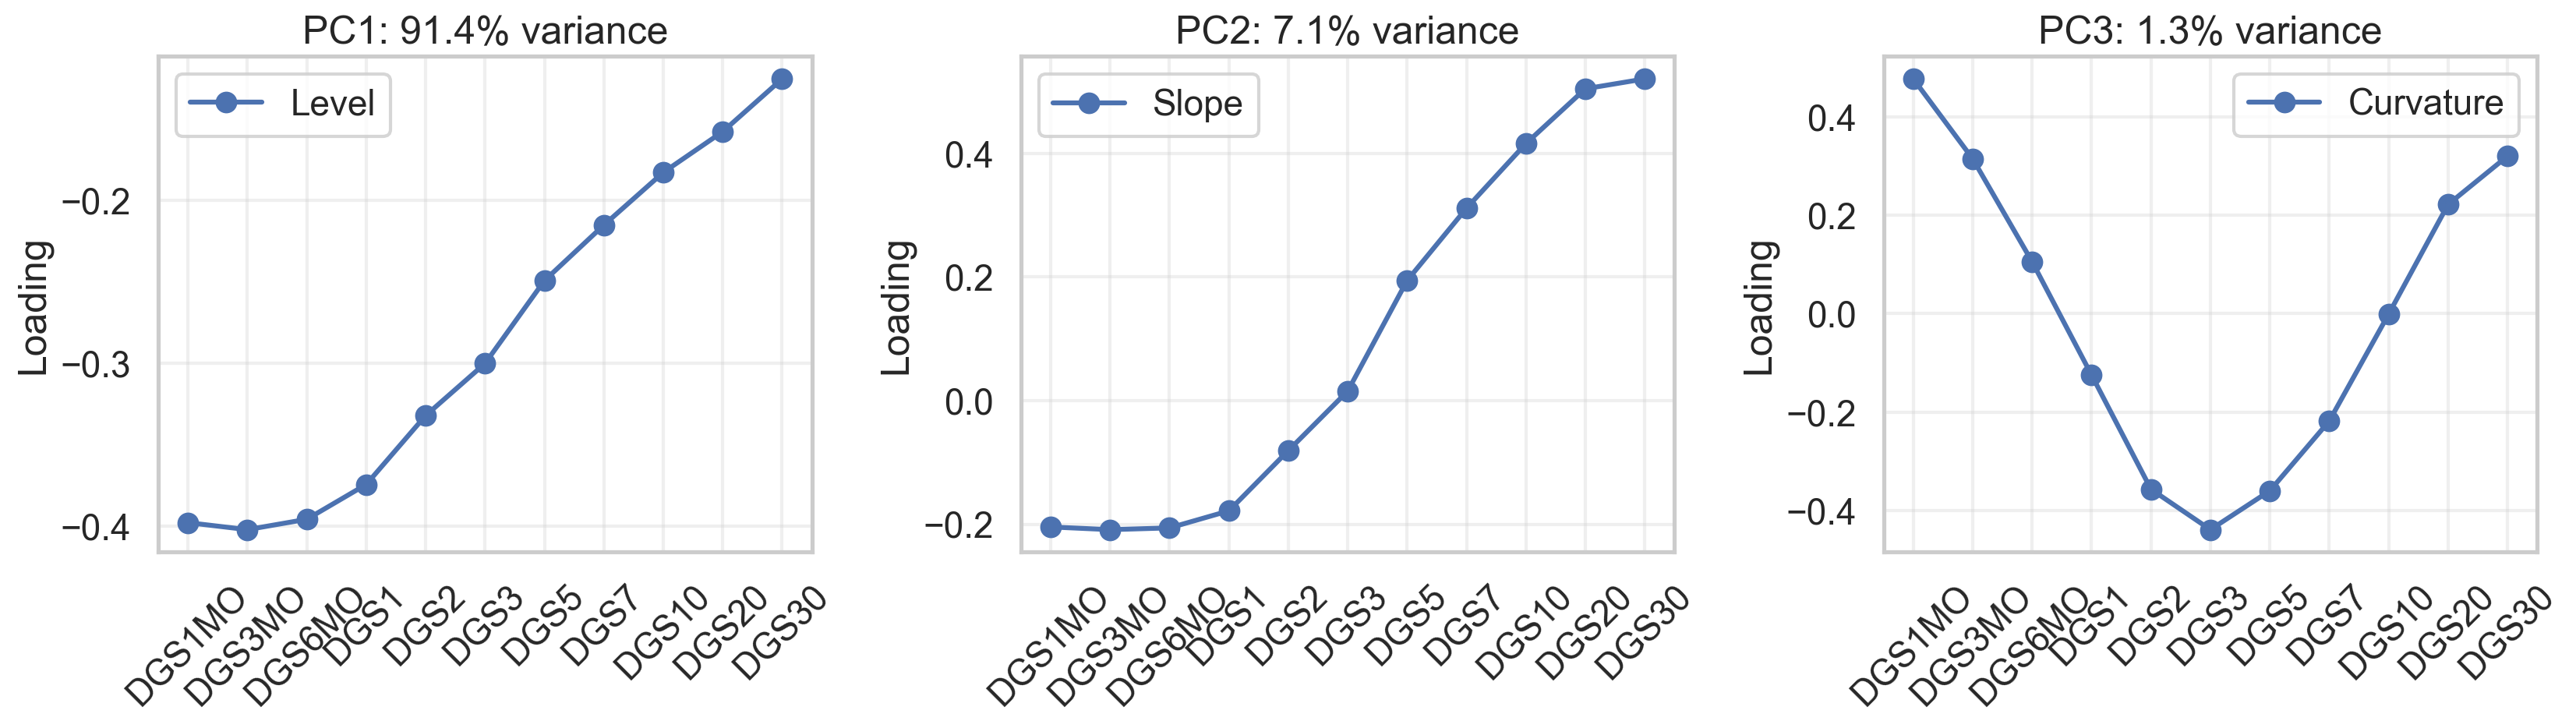

In [14]:
# Compute factor scores (projections onto principal components)
F = X @ U  # shape (T, M) - factor time series

components = ["Level", "Slope", "Curvature"]

# Plot the first 3 principal component loadings (shapes)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for i, factor in enumerate(components):
    axes[i].plot(fred_tickers, U[:, i], "o-", label=factor)
    axes[i].set_title(f"PC{i + 1}: {explained_variance[i]:.1%} variance")
    axes[i].set_ylabel("Loading")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()
plt.tight_layout()
plt.show()

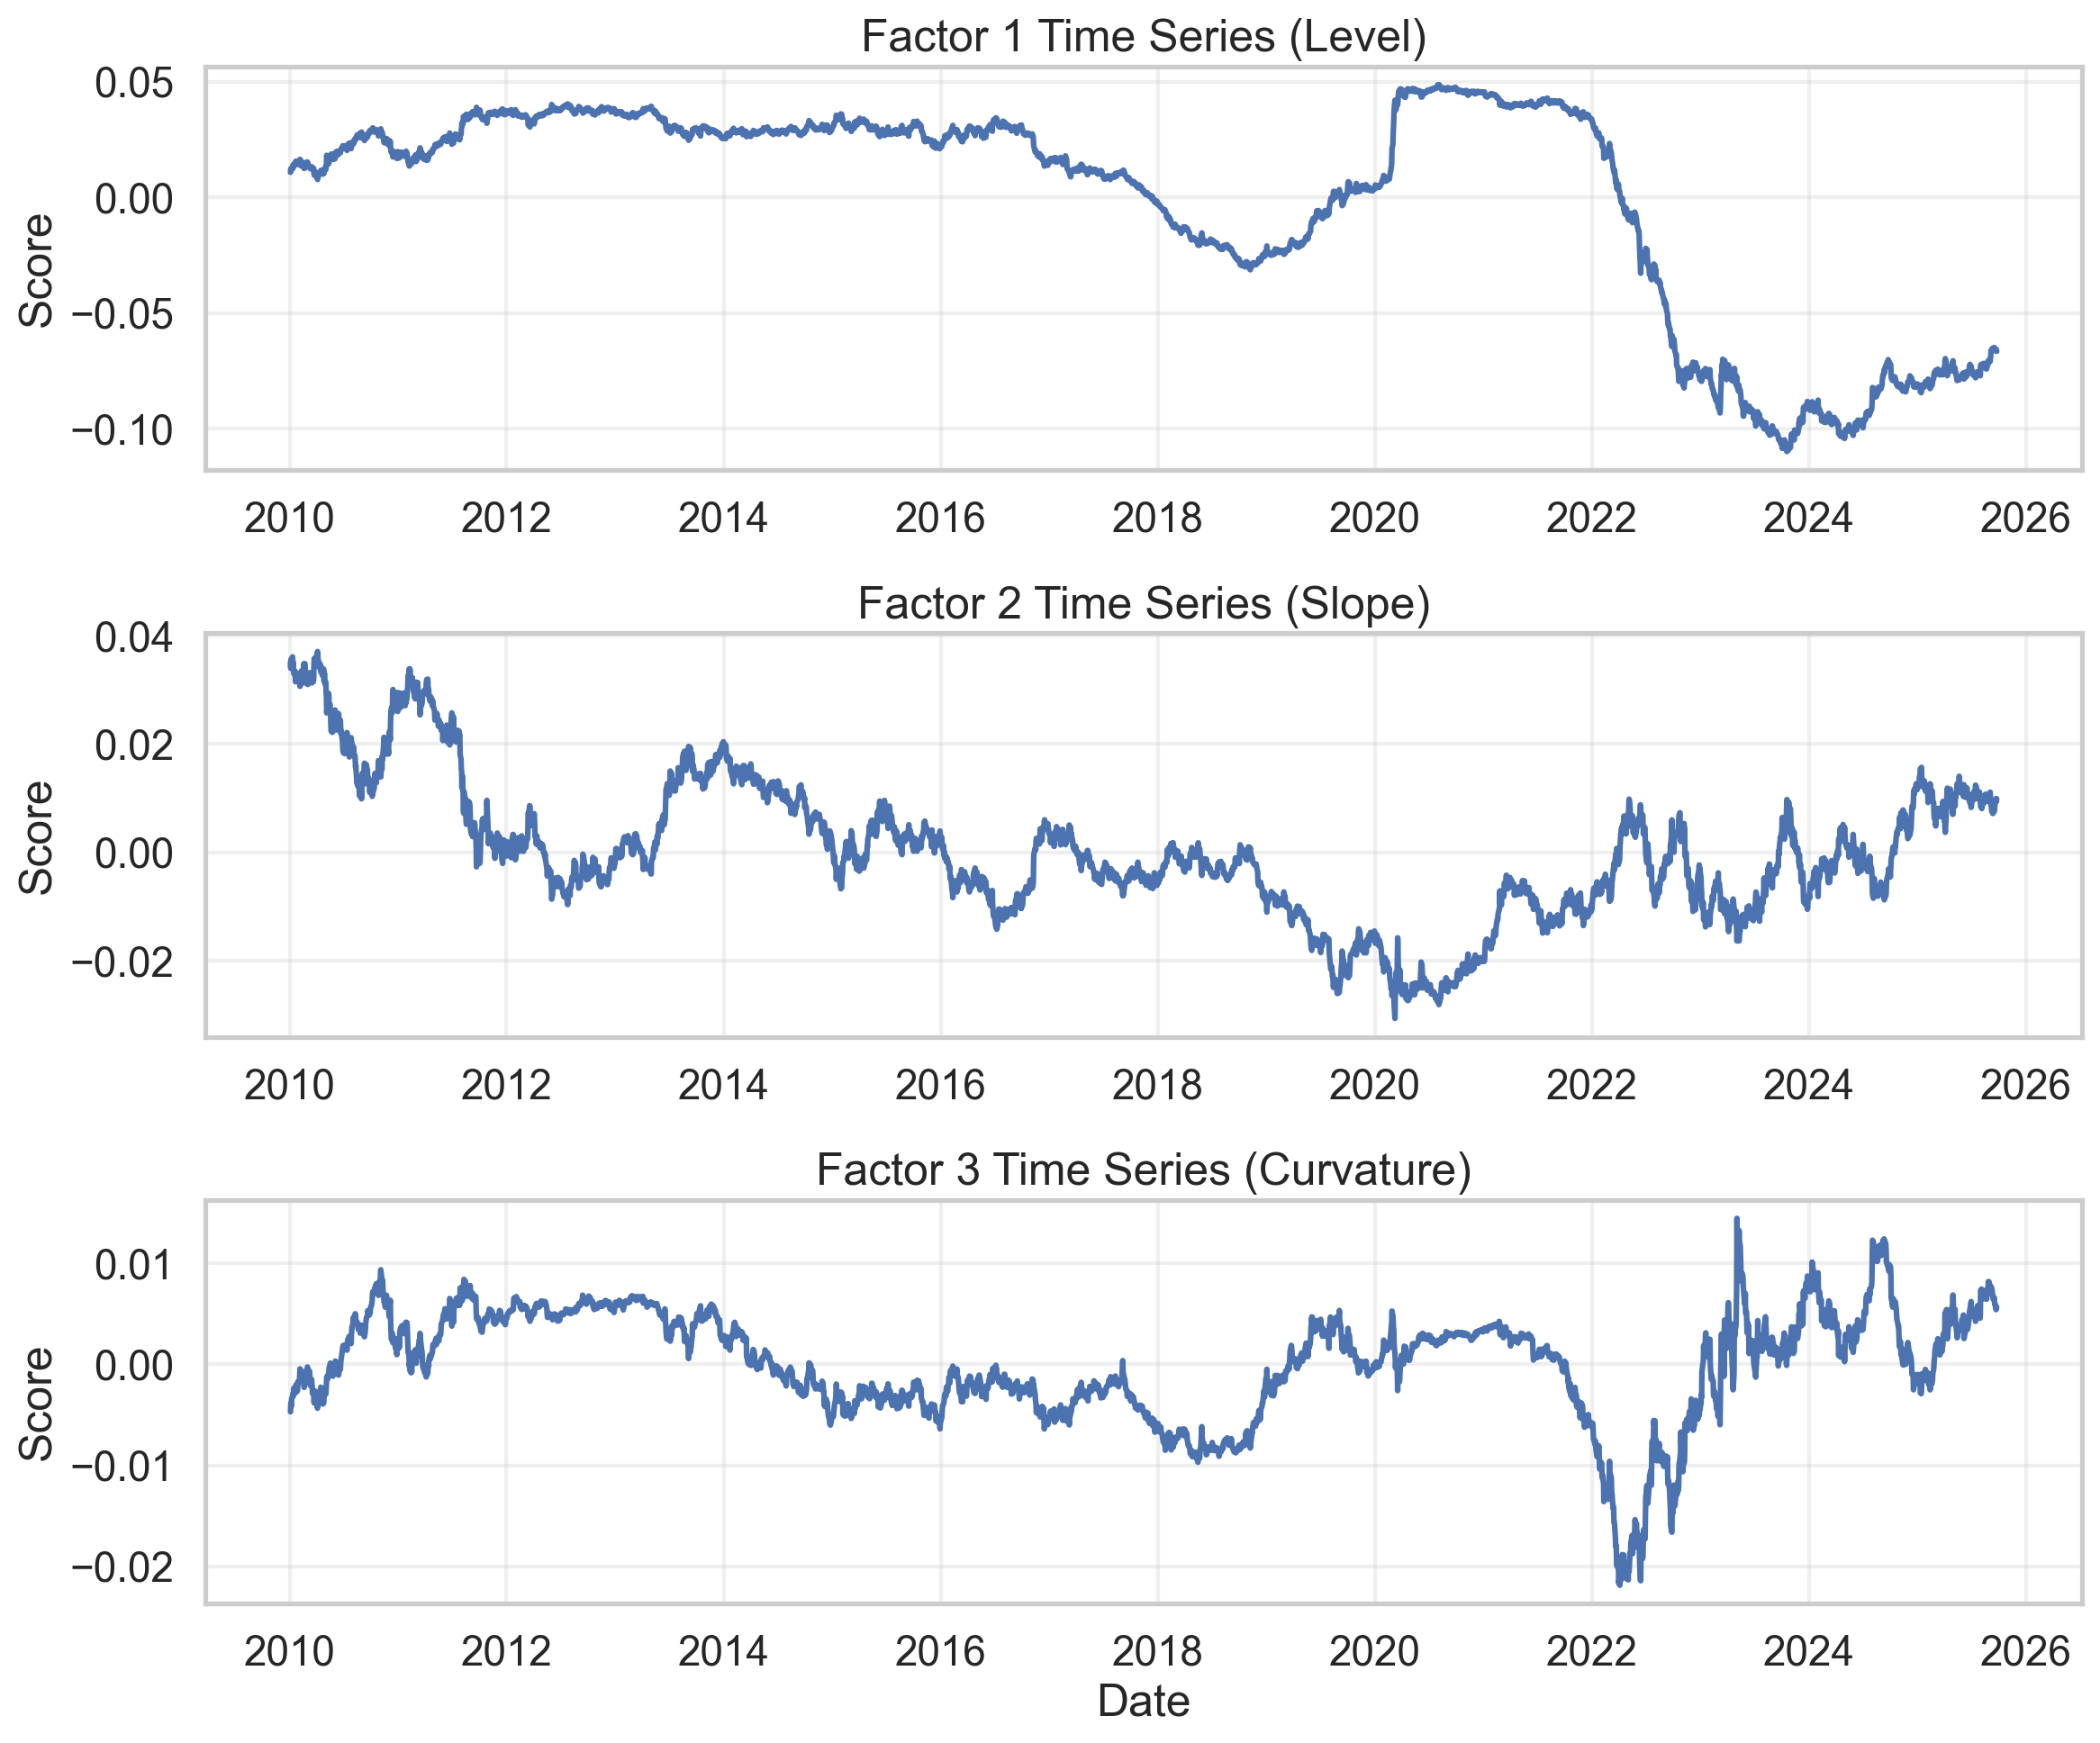

In [15]:
# Plot factor time series (scores over time)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for i in range(3):
    axes[i].plot(df_yields.index, F[:, i])
    axes[i].set_title(f"Factor {i + 1} Time Series ({components[i]})")
    axes[i].set_ylabel("Score")
    axes[i].grid(True, alpha=0.3)
axes[2].set_xlabel("Date")
plt.tight_layout()
plt.show()

Reconstruct yield curve using $K$ components and compare with actual

In [16]:
K = 3  # number of components to use

date = dt.datetime(2025, 9, 24)  # pick a date for reconstruction
date_idx = df_yields.index.get_loc(date)

# original yield curve
y_actual = df_yields.loc[date].values
y_actual = np.asarray(y_actual)

# reconstructed yield curve
y_reconstructed = mu.flatten() + F[date_idx, :K] @ U[:, :K].T

In [17]:
y_actual = np.asarray(y_actual)

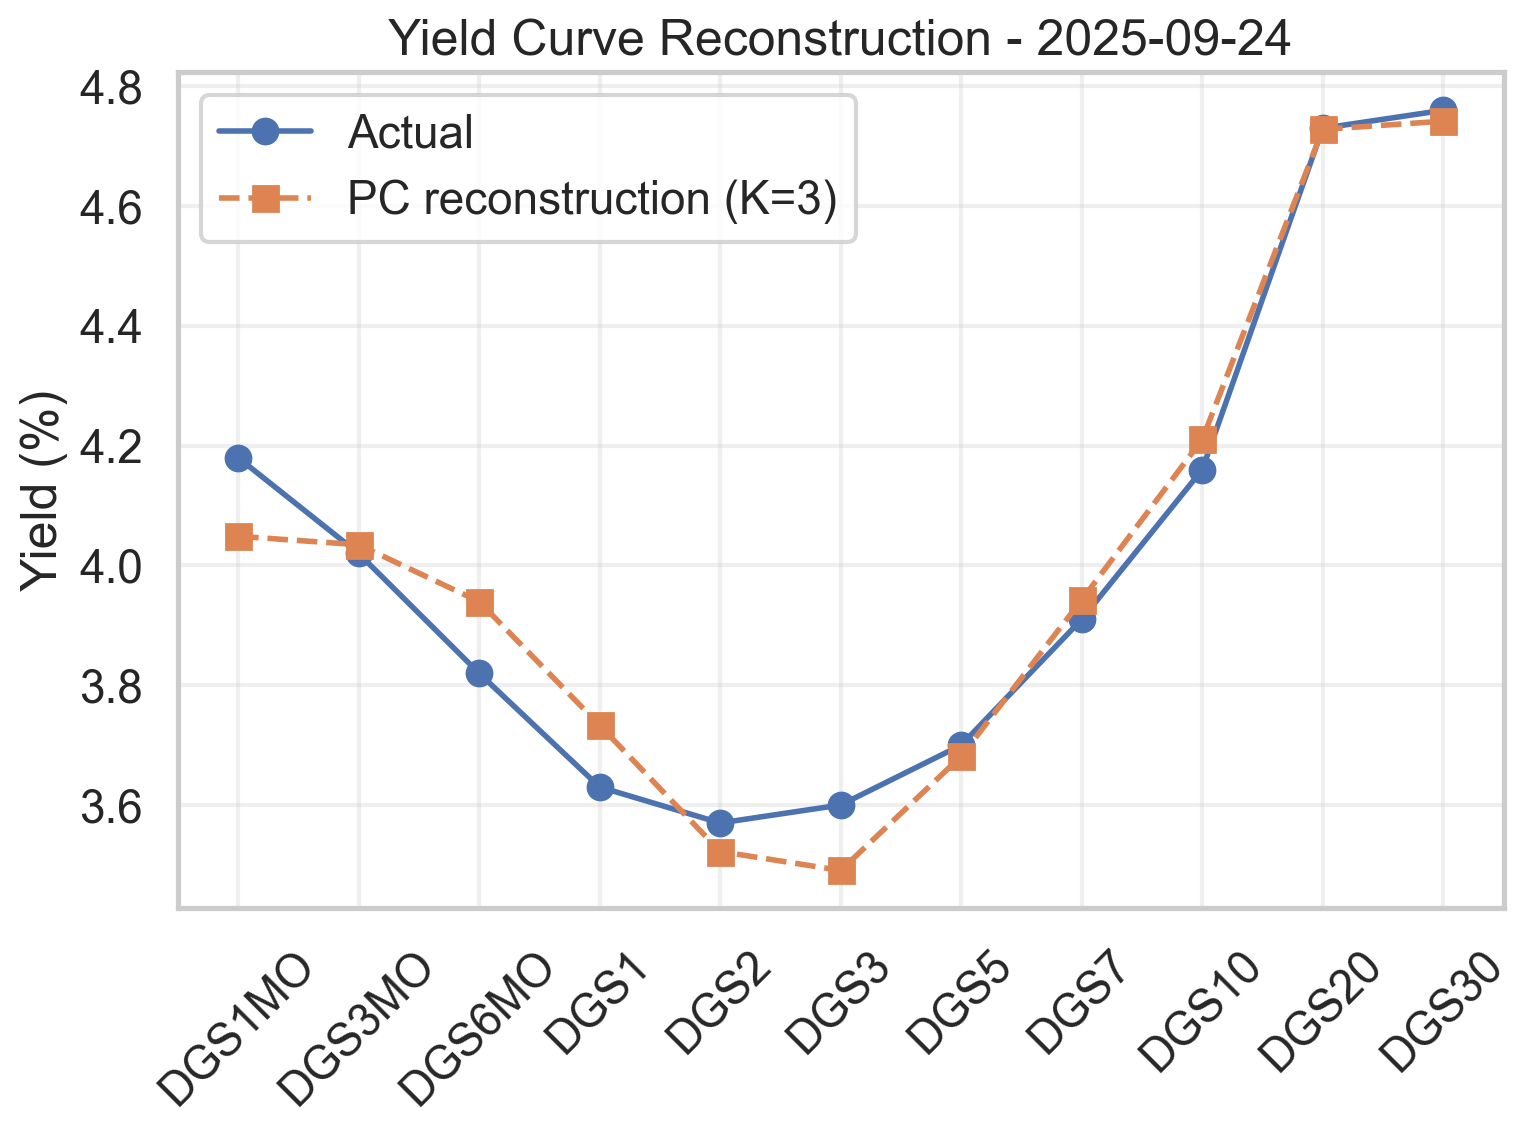

In [18]:
fig, ax = plt.subplots()
ax.plot(fred_tickers, 100 * y_actual, "o-", label="Actual", linewidth=2)
ax.plot(
    fred_tickers,
    100 * y_reconstructed,
    "s--",
    label=f"PC reconstruction (K={K})",
    linewidth=2,
)
ax.set_ylabel("Yield (%)")
ax.set_title(f"Yield Curve Reconstruction - {date.strftime('%Y-%m-%d')}")
ax.legend()
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Reconstruction error

In [19]:
error = np.abs(y_actual - y_reconstructed)
print(f"Mean absolute error: {error.mean():.4f}")
print(f"Max absolute error: {error.max():.4f}")

Mean absolute error: 0.0006
Max absolute error: 0.0013


# Nelson-Siegel

- Nelson-Siegel (NS) model is a popular approach for modeling the yield curve. 

- The model represents the yield curve as a function of three factors: level, slope, and curvature. 

- The dynamic version of the Nelson-Siegel model allows these factors to evolve over time, making it suitable for capturing changes in the yield curve.

$$
    y_t(\tau) = \beta_{0,t} + \beta_{1,t} \left( \frac{1 - e^{-\lambda \tau}}{\lambda \tau} \right) + \beta_{2,t} \left( \frac{1 - e^{-\lambda \tau}}{\lambda \tau} - e^{-\lambda \tau} \right)
$$

- The NS parameters 
    - $ \beta_{0,t} $: level (long term). This is the limit of the yield curve as $\tau \to \infty$.
    - $ \beta_{1,t} $: slope (short term). It controls the short-end of the yield curve relative to the long-end.
    - $ \beta_{2,t} $: curvature (medium term). This is the curvature of the yield curve. Adds "hump-shaped" deviations in the medium term.

    are not directly observable. They are typically inferred from the cross-section of yields at each date $t$

In [20]:
def f_slope(lbd, tau):
    return (1.0 - np.exp(-lbd * tau)) / (lbd * tau)


def f_curvature(lbd, tau):
    return f_slope(lbd, tau) - np.exp(-lbd * tau)


def nelson_siegel(tau, beta_0, beta_1, beta_2, lbd):
    return beta_0 + beta_1 * f_slope(lbd, tau) + beta_2 * f_curvature(lbd, tau)

In [21]:
beta_0 = 0.4  # long-term factor
beta_1 = -0.02  # short-term factor
beta_2 = 0.02  # medium-term factor
lbd = 0.5  # decay factor

taus = np.linspace(1e-3, 30, 100)

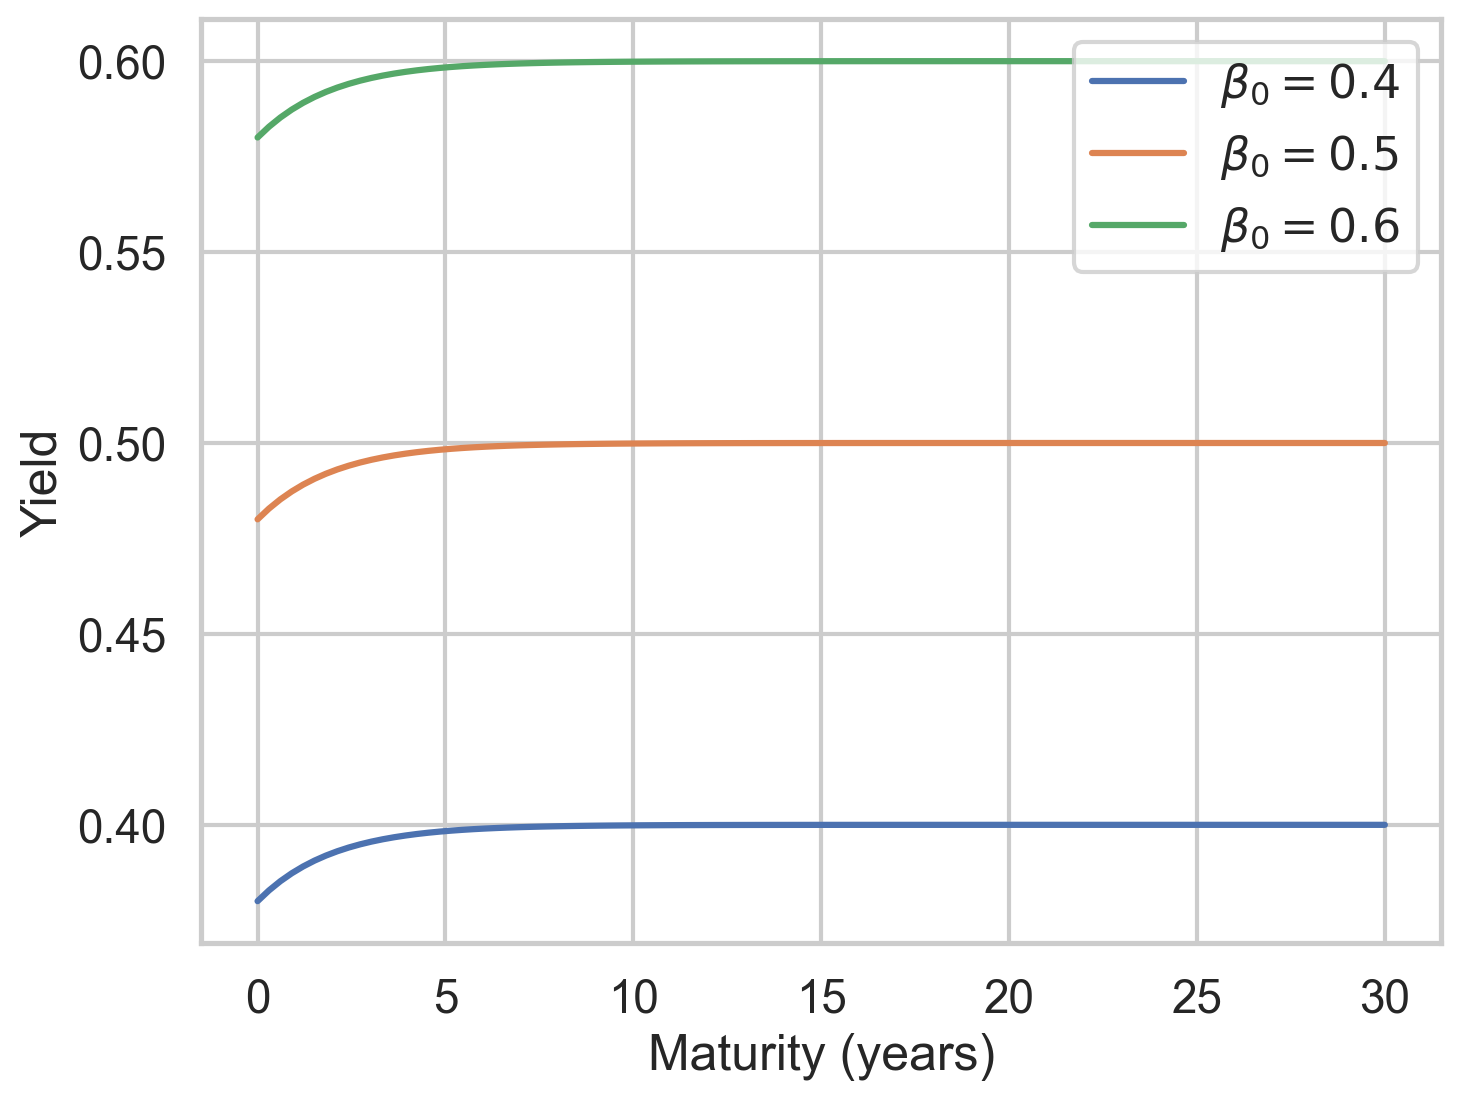

In [22]:
fig, ax = plt.subplots()
for _beta_0 in [0.4, 0.5, 0.6]:
    ax.plot(
        taus,
        nelson_siegel(taus, _beta_0, beta_1, beta_2, lbd),
        label=rf"$\beta_0={_beta_0}$",
    )
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield")
ax.legend()
plt.show()

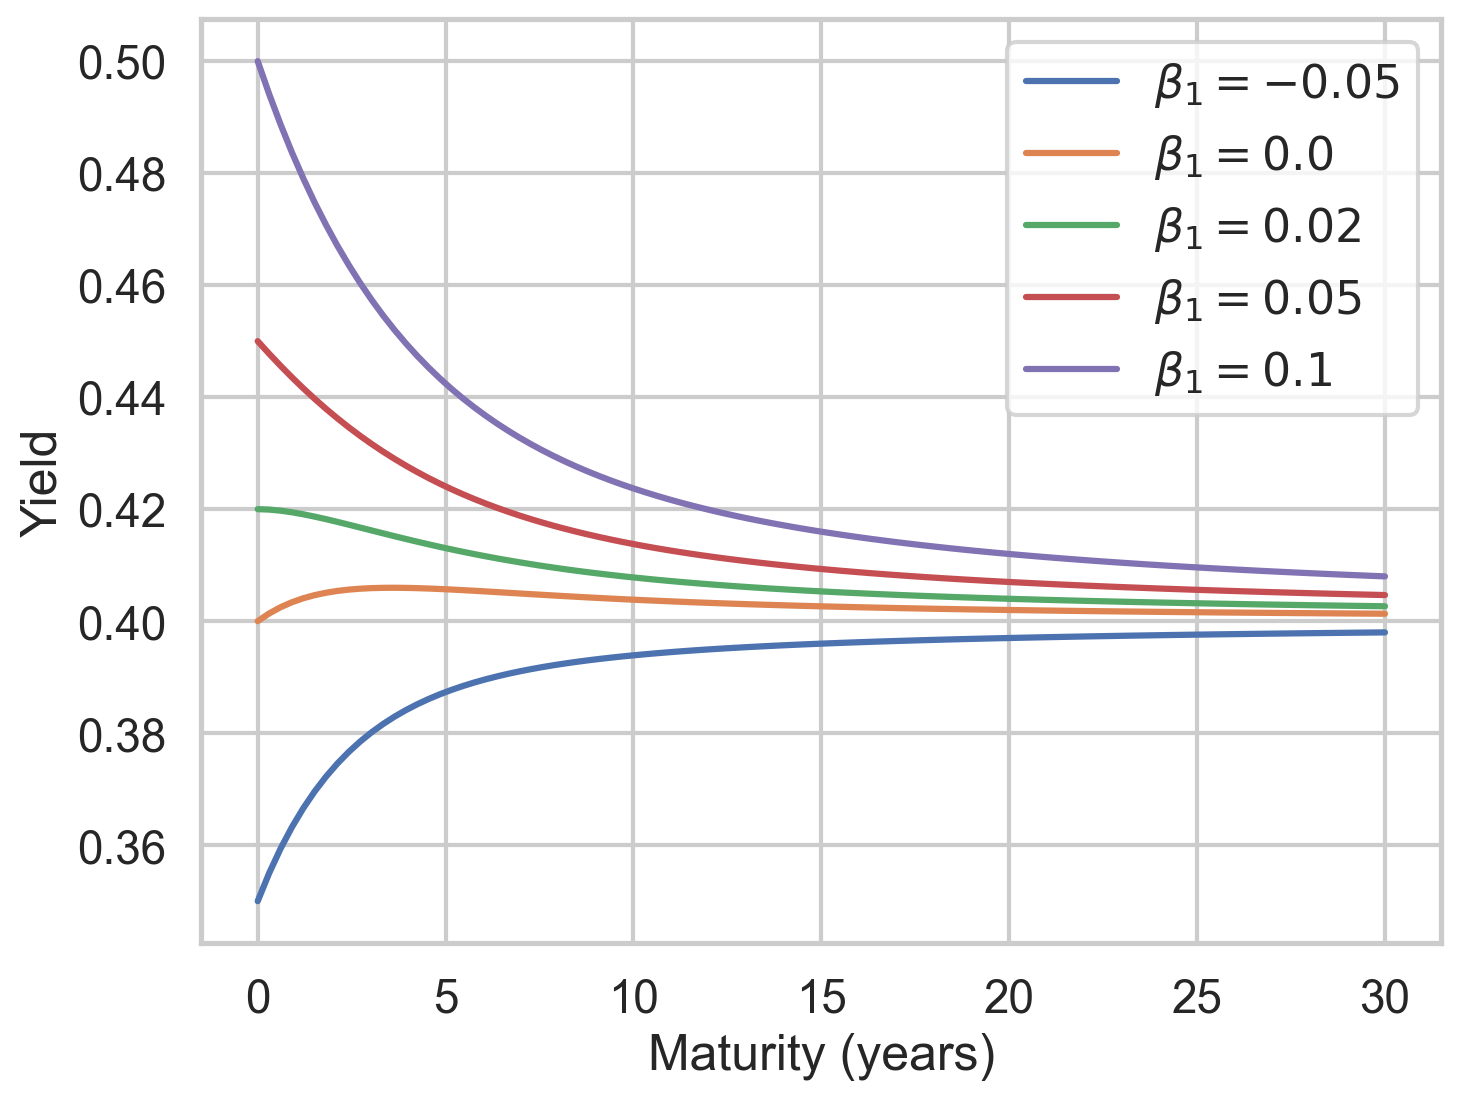

In [23]:
fig, ax = plt.subplots()
for _beta_1 in [-0.05, 0.0, 0.02, 0.05, 0.1]:
    ax.plot(
        taus,
        nelson_siegel(taus, beta_0, _beta_1, beta_2, lbd),
        label=rf"$\beta_1={_beta_1}$",
    )
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield")
ax.legend()
plt.show()

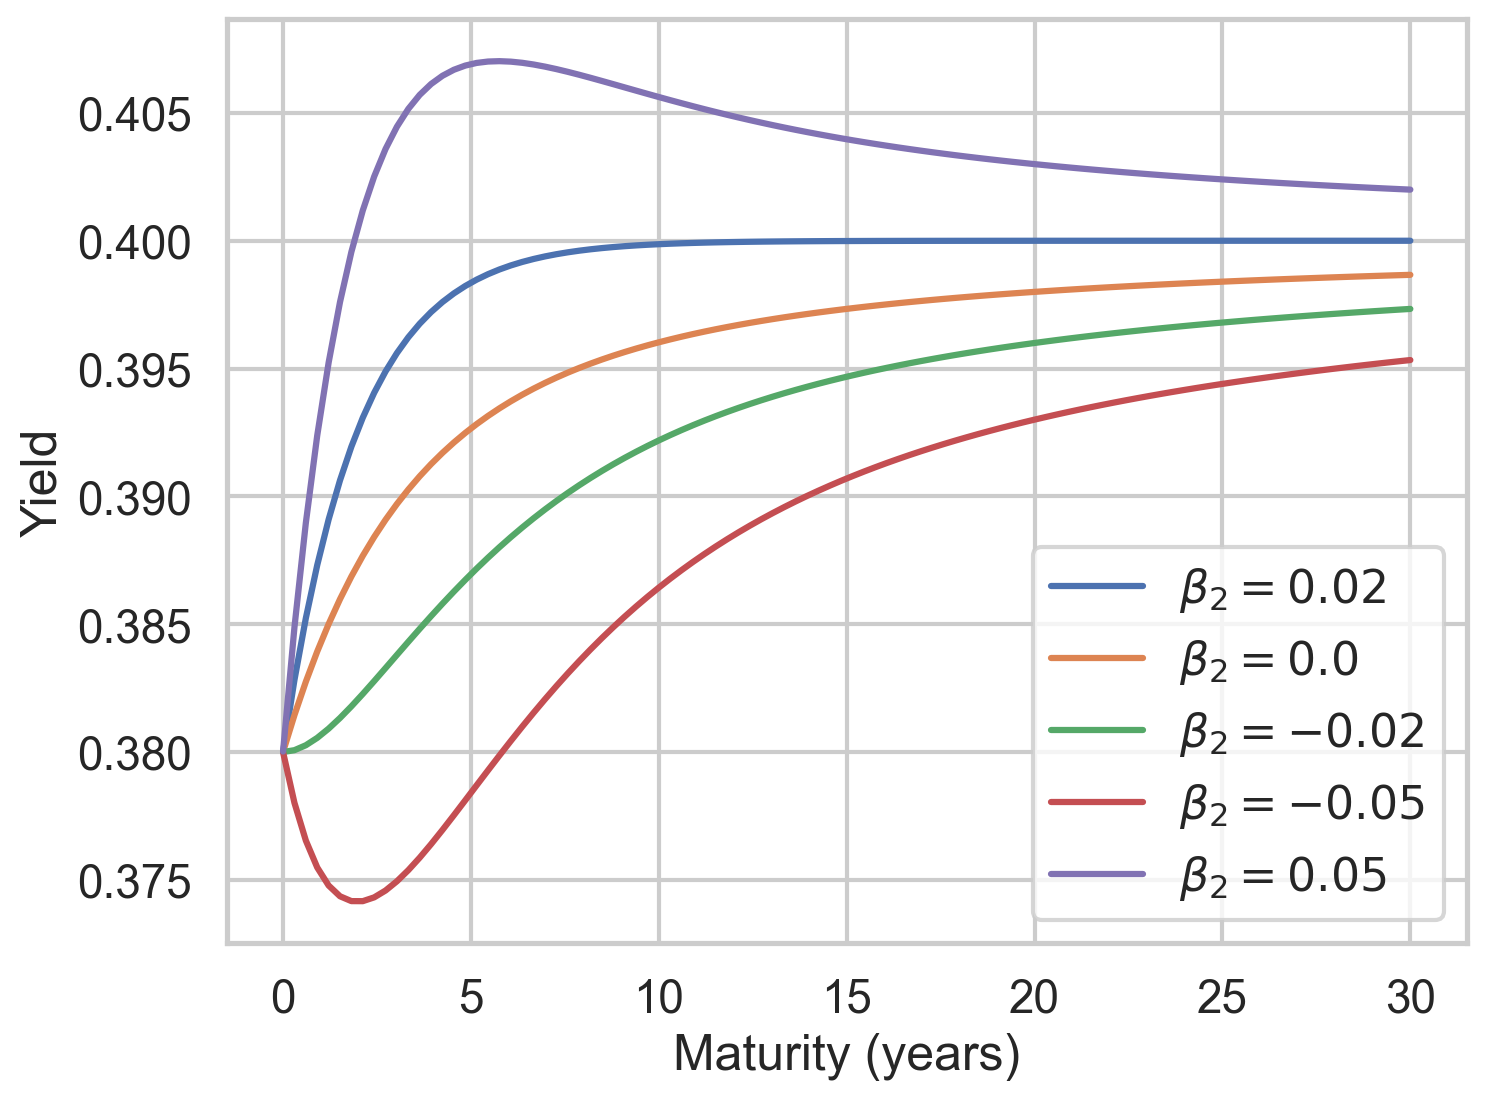

In [24]:
fig, ax = plt.subplots()
for _beta_2 in [0.02, 0.0, -0.02, -0.05, 0.05]:
    ax.plot(
        taus,
        nelson_siegel(taus, beta_0, beta_1, _beta_2, lbd),
        label=rf"$\beta_2={_beta_2}$",
    )
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield")
ax.legend()
plt.show()

In [25]:
# curve_fit example
from scipy.optimize import curve_fit

date = dt.datetime(2025, 9, 23)
yields_date = 100 * df_yields.loc[date].to_numpy()

In [26]:
time_to_mats = np.array([1 / 12, 3 / 12, 6 / 12, 1, 2, 3, 5, 7, 10, 20, 30])
p0 = [0.05, 0.01, 0.03, 0.02]  # initial guess for the parameters
fit_params, _ = curve_fit(f=nelson_siegel, xdata=time_to_mats, ydata=yields_date, p0=p0)

In [27]:
tau_ns = np.linspace(1e-3, 30, 100)
ns_fit_date = nelson_siegel(tau_ns, *fit_params)

In [28]:
fit_params

array([ 5.08343924, -0.92779964, -3.74619129,  0.49819296])

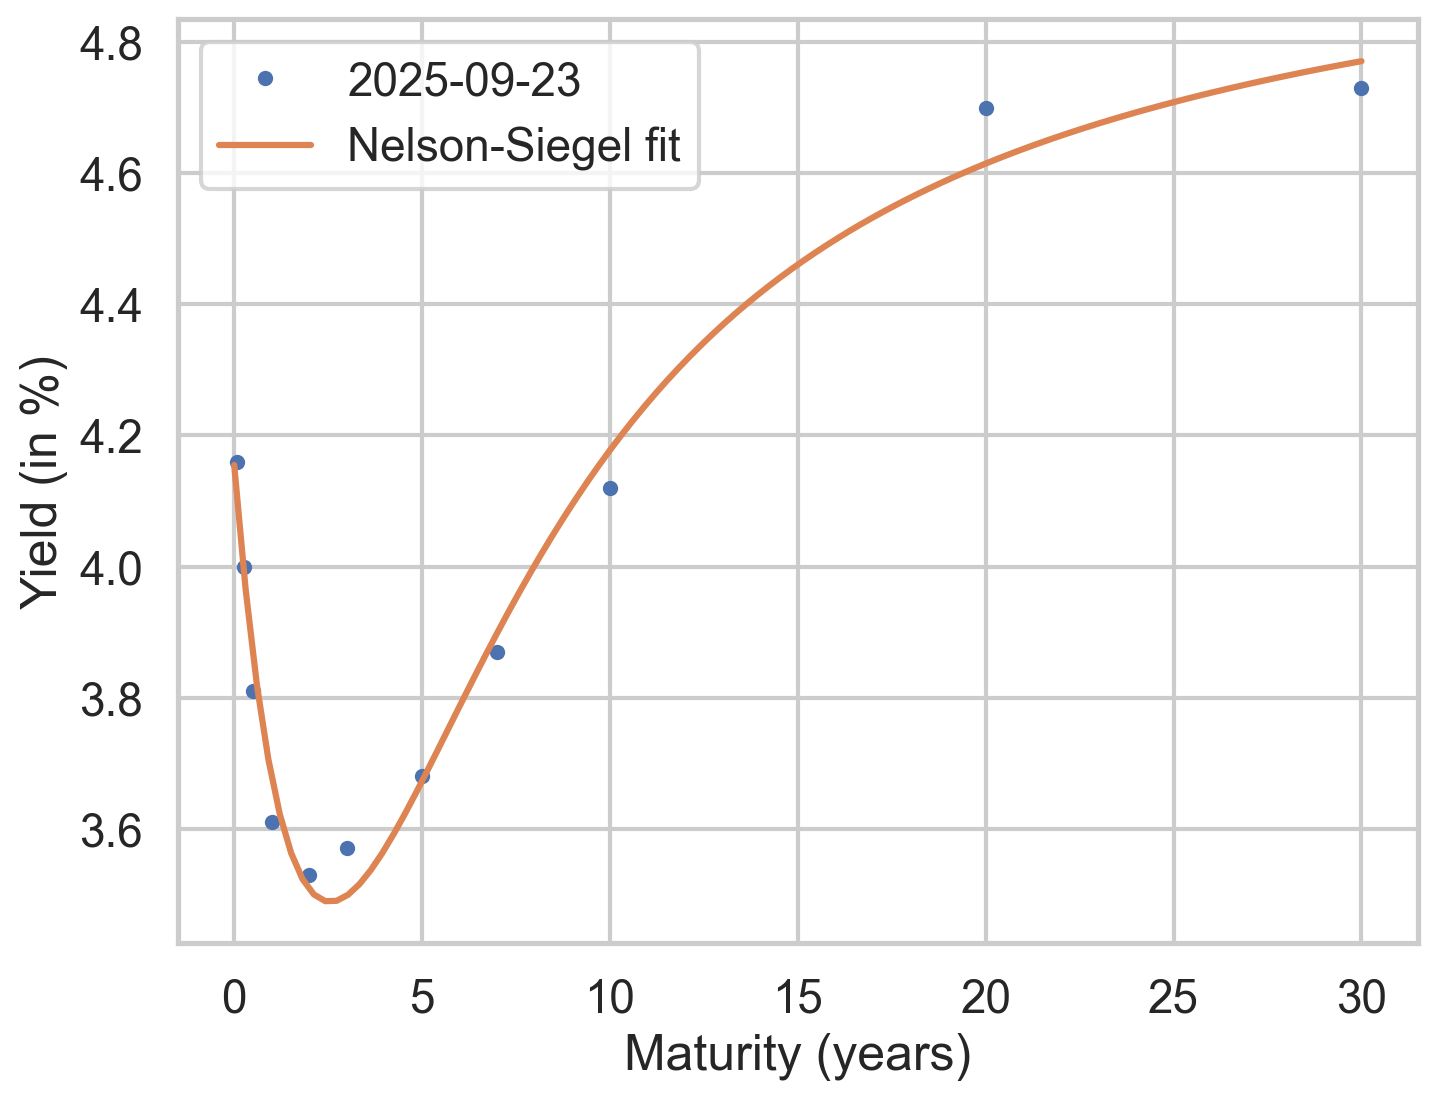

In [29]:
fig, ax = plt.subplots()
ax.plot(time_to_mats, yields_date, ".", label=f"{date.strftime('%Y-%m-%d')}")
ax.plot(tau_ns, ns_fit_date, "-", label="Nelson-Siegel fit")
ax.legend()
ax.set_ylabel("Yield (in %)")
ax.set_xlabel("Maturity (years)")
plt.show()